# Explore here

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer # Paso 2: Usamos TF-IDF
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack
import joblib

# Paso 1: Carga del conjunto de datos
url = "https://breathecode.herokuapp.com/asset/internal-link?id=932&path=url_spam.csv"
df = pd.read_csv(url)

EDA: Análisis Exploratorio de Datos

In [20]:
# verificar duplicados y distribución antes de procesar
print(" Análisis Exploratorio de Datos")
print(f"Dimensiones del dataset: {df.shape}")
print(f"Valores nulos:\n{df.isnull().sum()}")
print(f"Balance de clases:\n{df['is_spam'].value_counts(normalize=True)}")



 Análisis Exploratorio de Datos
Dimensiones del dataset: (2999, 5)
Valores nulos:
url           0
is_spam       0
url_length    0
count_dots    0
has_https     0
dtype: int64
Balance de clases:
is_spam
False    0.767923
True     0.232077
Name: proportion, dtype: float64


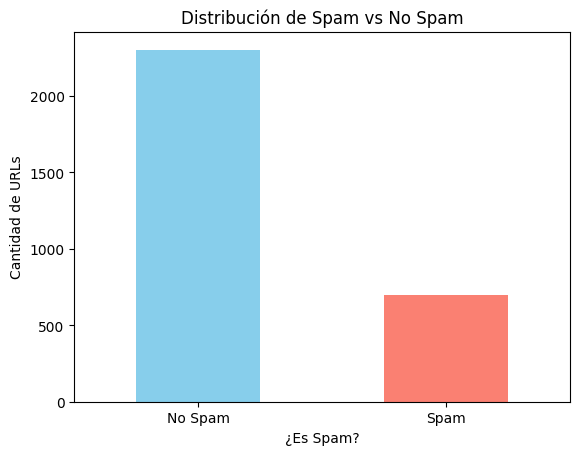

In [11]:
# Graficar el balance de clases
df['is_spam'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribución de Spam vs No Spam')
plt.xlabel('¿Es Spam?')
plt.ylabel('Cantidad de URLs')
plt.xticks([0, 1], ['No Spam', 'Spam'], rotation=0)
plt.show()

Análisis de la gráfica: "Distribución de Spam vs No Spam"

- Desbalance de datos: Como se puede obsevar, la barra azul (No Spam) es mucho más alta que la barra roja (Spam). Esto significa que el conjunto de datos tiene más ejemplos de enlaces seguros que de enlaces maliciosos.

¿Por qué es importante esto?

Si tuviéramos un balance perfecto (50% y 50%), el modelo tendría la misma cantidad de ejemplos para aprender de ambos casos.

Al tener más datos de "No Spam", el modelo se vuelve un experto reconociendo enlaces seguros 😉,
(Lo que es genial para entrenar).


feature engineering

In [21]:
# Feature Engineering
# se crean algunas variables adicionales que ayudan a detectar patrones de spam
df['url_length'] = df['url'].apply(len)
df['count_dots'] = df['url'].apply(lambda x: x.count('.'))
df['has_https'] = df['url'].apply(lambda x: 1 if 'https' in x else 0)

Procesamiento y escalado 

In [22]:
# Preprocesamiento de texto con TfidfVectorizer
vectorizer = TfidfVectorizer(token_pattern=r'(?u)\b\w\w+\b|[:/?&]')
X_text = vectorizer.fit_transform(df['url'])

# Vectorizadores

- CountVectorizer
¿Qué hace?: Literalmente cuenta cuántas veces aparece cada palabra en el texto. Si la palabra "login" aparece 3 veces, le da un valor de 3.

El problema: Es muy básico. Si una palabra aparece en casi todas las URLs (como "http"), el CountVectorizer le da muchísima importancia porque aparece muchas veces, aunque en realidad esa palabra no sirva para diferenciar si es spam o no.

- TfidfVectorizer (El "Inteligente"): Además de contar, le da menos peso a las palabras que aparecen en todas partes (como "http" o "www") y le da más peso a las palabras que son raras o únicas (como "oferta-ganadora-123").

¿Por qué lo escogí?: El TfidfVectorizer es mucho mejor para detectar spam porque se enfoca en las "señales" sospechosas y únicas, en lugar de dejarse engañar por palabras comunes que aparecen en todos los enlaces.

In [14]:
# Preprocesamiento de características numéricas
scaler = StandardScaler()
X_features = scaler.fit_transform(df[['url_length', 'count_dots', 'has_https']])

In [23]:
# se concatena el texto vectorizado con las variables numéricas
X_combined = hstack([X_text, X_features])

In [16]:
# Dividir el conjunto de datos en train y test
X_train, X_test, y_train, y_test = train_test_split(X_combined, df['is_spam'], test_size=0.2, random_state=42)


In [24]:
# Construcción y Optimización del modelo SVM
param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid = GridSearchCV(SVC(), param_grid, cv=3, verbose=2)
grid.fit(X_train, y_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END ...............................C=0.1, kernel=linear; total time=   0.1s
[CV] END ...............................C=0.1, kernel=linear; total time=   0.1s
[CV] END ...............................C=0.1, kernel=linear; total time=   0.2s
[CV] END ..................................C=0.1, kernel=rbf; total time=   0.2s
[CV] END ..................................C=0.1, kernel=rbf; total time=   0.2s
[CV] END ..................................C=0.1, kernel=rbf; total time=   0.2s
[CV] END .................................C=1, kernel=linear; total time=   0.1s
[CV] END .................................C=1, kernel=linear; total time=   0.1s
[CV] END .................................C=1, kernel=linear; total time=   0.1s
[CV] END ....................................C=1, kernel=rbf; total time=   0.1s
[CV] END ....................................C=1, kernel=rbf; total time=   0.1s
[CV] END ....................................C=1,

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate paramete

El modelo se optimizó con GridSearchCV para encontrar los hiperparámetros que ofrecen el mejor rendimiento.

In [18]:
# Evaluación del modelo
print("\n--- Resultados del Modelo ---")
print("Mejor configuración encontrada:", grid.best_params_)
print(classification_report(y_test, grid.best_estimator_.predict(X_test)))



--- Resultados del Modelo ---
Mejor configuración encontrada: {'C': 10, 'kernel': 'rbf'}
              precision    recall  f1-score   support

       False       0.97      0.99      0.98       455
        True       0.98      0.92      0.95       145

    accuracy                           0.97       600
   macro avg       0.98      0.96      0.97       600
weighted avg       0.98      0.97      0.97       600



Análisis Resumido de los Resultados

- Configuración:El modelo decidió que la mejor forma de aprender es usando una configuración llamada {'C': 10, 'kernel': 'rbf'}. 

- Precision: Cuando el modelo dice que un enlace es spam, acierta el 98% de las veces.

- Recall: El modelo logra "cazar" el 92% de todas las URLs de spam que existen en la prueba. Se le escapa un 8%, lo cual no esta mal para un proyecto de aprendizaje.

- Accuracy: En total, el modelo acierta el 97% de todas sus predicciones.

In [25]:
# Guardar el modelo entrenado
joblib.dump(grid.best_estimator_, 'svm_spam_detector.pkl')
print("Modelo guardado exitosamente como 'svm_spam_detector.pkl'")

Modelo guardado exitosamente como 'svm_spam_detector.pkl'
